# 03 - MediaPipe Face Mesh Lip Landmark & Crop Experiment (112×112 RGB)
## Tai Phake Visual Speech Recognition (VSR) Project

**Objective**: Implement, evaluate, and visually inspect a higher-resolution **112×112 RGB MediaPipe mouth-crop dataset** across all 30 speakers ($s_1 \dots s_{30}$) and 11 digit classes ($d_0 \dots d_{10}$) in the Tai Phake dataset ($330$ utterances, $13,610$ raw frames).

---

### Pipeline Specifications (Identical to 96×96 with Higher Pixel Density):
1. **Face Mesh Landmark Extraction**: MediaPipe FaceLandmarker CPU inference ($478$ 3D points) detecting the 40 canonical lip contour points (`FACE_LANDMARKS_LIPS`).
2. **Bounding Box with Comfort Margin**: Identical bounding box calculation with horizontal and vertical context padding ($P_x = 15\text{ px}, P_y = 10\text{ px}$).
3. **Direct 112×112 RGB Crop**: Directly crops the mouth region from the original-resolution frame and resizes directly to **112×112 pixels** via `cv2.INTER_AREA`.
   - **No letterboxing** (no synthetic artificial borders).
   - **No pre-squaring** (no extra nose/chin forcing).
   - **No full-face squashing**.
   - **Full RGB color preserved**.
4. **Complete Isolation**: Dedicated experiment dataset saved to `data/experiments/mediapipe_lips_dataset_112x112/` leaving the 96×96 dataset and all Dlib datasets untouched.
5. **Visual Verification & Side-by-Side Comparison**: Contact sheets and direct 96×96 vs 112×112 resolution comparisons saved in `results/mediapipe_preview_112x112/`.

In [1]:
import os
import sys
import time
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from mediapipe.tasks.python.vision import FaceLandmarksConnections

# Project paths
PROJECT_ROOT = Path("..").resolve()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "digit"
if not RAW_DATA_DIR.exists():
    RAW_DATA_DIR = PROJECT_ROOT / "data" / "experiments" / "digit"

DATASET_96_DIR = PROJECT_ROOT / "data" / "experiments" / "mediapipe_lips_dataset_96x96"
OUTPUT_DATASET_DIR = PROJECT_ROOT / "data" / "experiments" / "mediapipe_lips_dataset_112x112"
RESULTS_DIR = PROJECT_ROOT / "results" / "mediapipe_preview_112x112"
MODEL_PATH = PROJECT_ROOT / "models" / "mediapipe" / "face_landmarker.task"

# Target dimensions
TARGET_WIDTH = 112
TARGET_HEIGHT = 112
PAD_X = 15
PAD_Y = 10

print(f"Project Root:          {PROJECT_ROOT}")
print(f"Raw Frames Directory:  {RAW_DATA_DIR}")
print(f"Output 112x112 Dataset:{OUTPUT_DATASET_DIR}")
print(f"Existing 96x96 Dataset:{DATASET_96_DIR}")
print(f"Results / Preview:     {RESULTS_DIR}")
print(f"Target Resolution:     {TARGET_WIDTH}x{TARGET_HEIGHT} (RGB)")

Project Root:          /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading
Raw Frames Directory:  /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/data/digit
Output 112x112 Dataset:/Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/data/experiments/mediapipe_lips_dataset_112x112
Existing 96x96 Dataset:/Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/data/experiments/mediapipe_lips_dataset_96x96
Results / Preview:     /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/mediapipe_preview_112x112
Target Resolution:     112x112 (RGB)


## 1. MediaPipe FaceLandmarker Initialization & Lip Topology

Initializes the CPU-delegated FaceLandmarker using `models/mediapipe/face_landmarker.task` and extracts the 40 canonical lip landmark indices.

In [2]:
LIP_CONNECTIONS = FaceLandmarksConnections.FACE_LANDMARKS_LIPS
LIP_LANDMARK_INDICES = sorted(list(set([c.start for c in LIP_CONNECTIONS] + [c.end for c in LIP_CONNECTIONS])))

print(f"Total lip landmark points: {len(LIP_LANDMARK_INDICES)}")

def create_detector(model_asset_path: Path) -> vision.FaceLandmarker:
    base_options = python.BaseOptions(
        model_asset_path=str(model_asset_path),
        delegate=python.BaseOptions.Delegate.CPU
    )
    options = vision.FaceLandmarkerOptions(
        base_options=base_options,
        output_face_blendshapes=False,
        output_facial_transformation_matrixes=False,
        num_faces=1
    )
    return vision.FaceLandmarker.create_from_options(options)

detector = create_detector(MODEL_PATH)
print("MediaPipe FaceLandmarker detector initialized successfully.")

Total lip landmark points: 40


MediaPipe FaceLandmarker detector initialized successfully.


I0000 00:00:1791044024.701762 22722565 init-domain.cc:128] Fiber init: default domain = pthread, concurrency = 11, prefix = pthread-default
W0000 00:00:1791044024.702160 22722565 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1791044024.772976 22722565 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M4
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1791044024.774286 22722573 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1791044024.779913 22722574 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


## 2. Lip Bounding Box Detection & 112×112 Cropping Functions

Extracts the mouth ROI from the raw frame and resizes directly to $112\times 112$ pixels.

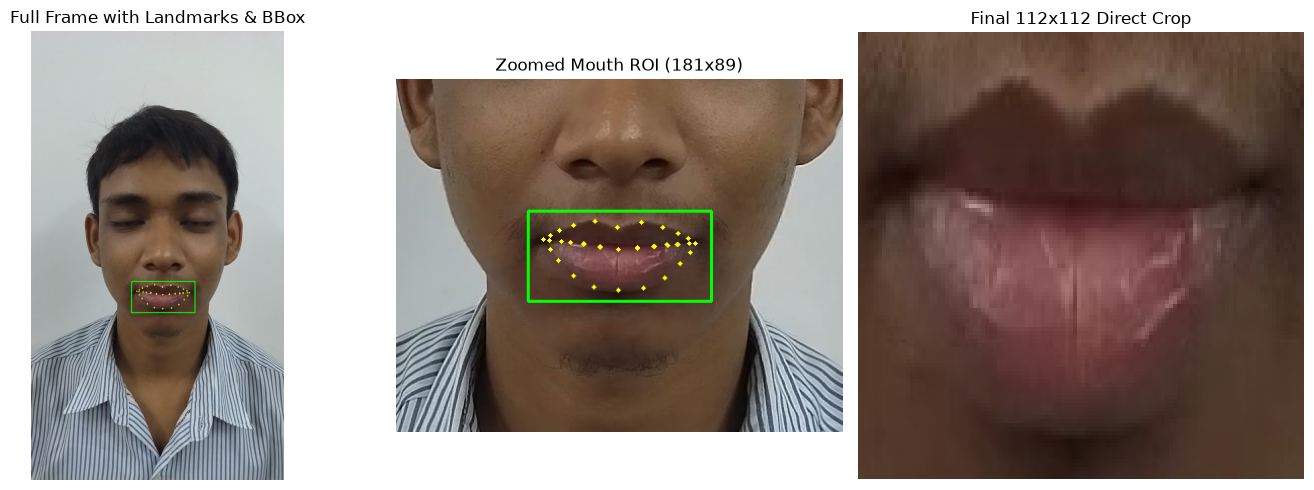

Sample bbox: (285, 713) to (466, 802), Crop shape: (112, 112, 3)


In [3]:
def detect_mouth_bbox(
    img_bgr: np.ndarray,
    detector: vision.FaceLandmarker,
    pad_x: int = PAD_X,
    pad_y: int = PAD_Y,
) -> Tuple[Optional[Tuple[int, int, int, int]], Optional[np.ndarray], Optional[str]]:
    h, w = img_bgr.shape[:2]
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
    
    try:
        detection_result = detector.detect(mp_img)
    except Exception as e:
        return None, None, f"Detection exception: {e}"
    
    if not detection_result.face_landmarks:
        return None, None, "No face detected"
    
    landmarks = detection_result.face_landmarks[0]
    lip_pts = np.array(
        [[landmarks[idx].x * w, landmarks[idx].y * h] for idx in LIP_LANDMARK_INDICES],
        dtype=np.float32
    )
    
    x_min = np.min(lip_pts[:, 0])
    x_max = np.max(lip_pts[:, 0])
    y_min = np.min(lip_pts[:, 1])
    y_max = np.max(lip_pts[:, 1])
    
    x1 = max(0, int(round(x_min - pad_x)))
    y1 = max(0, int(round(y_min - pad_y)))
    x2 = min(w, int(round(x_max + pad_x)))
    y2 = min(h, int(round(y_max + pad_y)))
    
    if (x2 - x1) <= 0 or (y2 - y1) <= 0:
        return None, lip_pts, f"Invalid crop dimensions: ({x1}, {y1}) to ({x2}, {y2})"
    
    return (x1, y1, x2, y2), lip_pts, None


def extract_and_resize_lip(
    img_bgr: np.ndarray,
    bbox: Tuple[int, int, int, int],
    target_w: int = TARGET_WIDTH,
    target_h: int = TARGET_HEIGHT,
) -> np.ndarray:
    x1, y1, x2, y2 = bbox
    crop = img_bgr[y1:y2, x1:x2]
    return cv2.resize(crop, (target_w, target_h), interpolation=cv2.INTER_AREA)


# Demonstrate on sample frame s1/d0/frame_0001.jpg
sample_path = RAW_DATA_DIR / "s1" / "d0" / "frame_0001.jpg"
sample_bgr = cv2.imread(str(sample_path))
bbox, lip_pts, err = detect_mouth_bbox(sample_bgr, detector)

if bbox is not None:
    x1, y1, x2, y2 = bbox
    crop_112 = extract_and_resize_lip(sample_bgr, bbox, target_w=112, target_h=112)
    
    vis_raw = sample_bgr.copy()
    for pt in lip_pts.astype(int):
        cv2.circle(vis_raw, tuple(pt), 2, (0, 255, 255), -1)
    cv2.rectangle(vis_raw, (x1, y1), (x2, y2), (0, 255, 0), 2)
    
    z_margin = 130
    zx1, zy1 = max(0, x1 - z_margin), max(0, y1 - z_margin)
    zx2, zy2 = min(sample_bgr.shape[1], x2 + z_margin), min(sample_bgr.shape[0], y2 + z_margin)
    zoomed = vis_raw[zy1:zy2, zx1:zx2]
    
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 5))
    ax1.imshow(cv2.cvtColor(vis_raw, cv2.COLOR_BGR2RGB))
    ax1.set_title("Full Frame with Landmarks & BBox")
    ax1.axis("off")
    
    ax2.imshow(cv2.cvtColor(zoomed, cv2.COLOR_BGR2RGB))
    ax2.set_title(f"Zoomed Mouth ROI ({x2-x1}x{y2-y1})")
    ax2.axis("off")
    
    ax3.imshow(cv2.cvtColor(crop_112, cv2.COLOR_BGR2RGB))
    ax3.set_title("Final 112x112 Direct Crop")
    ax3.axis("off")
    plt.tight_layout()
    plt.show()
    
    print(f"Sample bbox: ({x1}, {y1}) to ({x2}, {y2}), Crop shape: {crop_112.shape}")

## 3. Dataset Generation & Execution (112×112)

Generated via the reproducible standalone script `scripts/create_mediapipe_112x112_dataset.py` across all 30 speakers and 11 digits.
Below we load and inspect the master CSV report `mediapipe_crop_report.csv`.

In [4]:
report_csv_path = OUTPUT_DATASET_DIR / "mediapipe_crop_report.csv"
if not report_csv_path.exists():
    report_csv_path = RESULTS_DIR / "mediapipe_crop_report.csv"

if report_csv_path.exists():
    df = pd.read_csv(report_csv_path)
    print(f"Loaded 112x112 crop report: {len(df)} total frame records.")
    display(df.head(10))
else:
    print(f"Report not yet found at {report_csv_path}.")

Loaded 112x112 crop report: 13610 total frame records.


,speaker,digit,frame,detected,x1,y1,x2,y2,crop_width,crop_height,error
0,s1,d0,frame_0001.jpg,True,285.0,713.0,466.0,802.0,181.0,89.0,NaN
1,s1,d0,frame_0002.jpg,True,287.0,712.0,463.0,802.0,176.0,90.0,NaN
2,s1,d0,frame_0003.jpg,True,286.0,710.0,462.0,807.0,176.0,97.0,NaN
3,s1,d0,frame_0004.jpg,True,286.0,708.0,462.0,813.0,176.0,105.0,NaN
4,s1,d0,frame_0005.jpg,True,286.0,707.0,461.0,820.0,175.0,113.0,NaN
5,s1,d0,frame_0006.jpg,True,287.0,710.0,461.0,824.0,174.0,114.0,NaN
6,s1,d0,frame_0007.jpg,True,286.0,713.0,460.0,822.0,174.0,109.0,NaN
7,s1,d0,frame_0008.jpg,True,283.0,720.0,459.0,814.0,176.0,94.0,NaN
8,s1,d0,frame_0009.jpg,True,283.0,728.0,457.0,802.0,174.0,74.0,NaN
9,s1,d0,frame_0010.jpg,True,282.0,731.0,459.0,790.0,177.0,59.0,NaN


## 4. Preprocessing Quality & Statistical Analysis

Quantitative verification of extraction metrics across the dataset.

MediaPipe 112x112 Preprocessing Quality Summary
Total frames processed:          13,610
Successful MediaPipe detections: 13,554
Failed detections:               56
Detection success percentage:    99.59%
Number of utterances processed:  330
Output dataset path:             /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/data/experiments/mediapipe_lips_dataset_112x112
Preview path:                    /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/mediapipe_preview_112x112


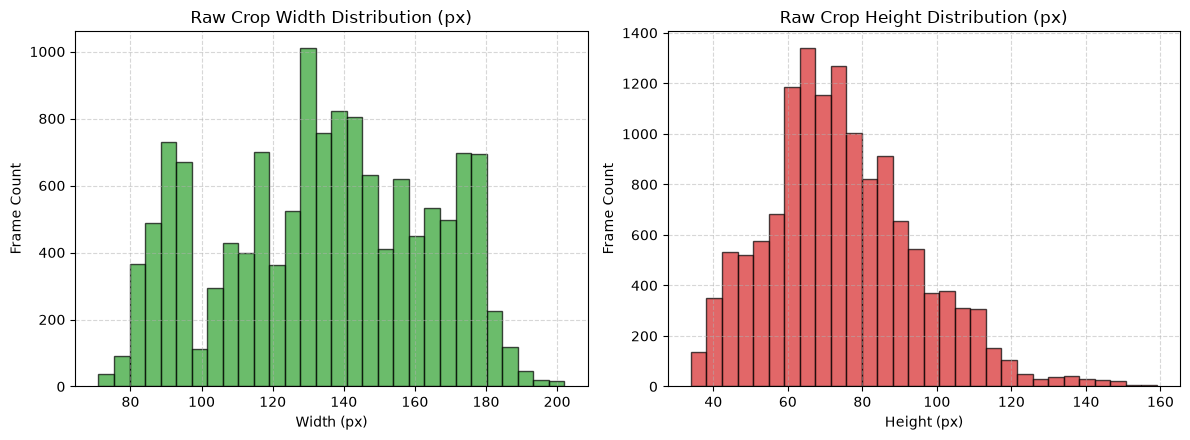

In [5]:
if 'df' in locals() and not df.empty:
    total_frames = len(df)
    successful = int(df['detected'].sum())
    failed = total_frames - successful
    success_rate = (successful / total_frames) * 100.0
    num_utterances = df.groupby(['speaker', 'digit']).ngroups
    
    print("=" * 65)
    print("MediaPipe 112x112 Preprocessing Quality Summary")
    print("=" * 65)
    print(f"Total frames processed:          {total_frames:,}")
    print(f"Successful MediaPipe detections: {successful:,}")
    print(f"Failed detections:               {failed:,}")
    print(f"Detection success percentage:    {success_rate:.2f}%")
    print(f"Number of utterances processed:  {num_utterances}")
    print(f"Output dataset path:             {OUTPUT_DATASET_DIR}")
    print(f"Preview path:                    {RESULTS_DIR}")
    print("=" * 65)
    
    valid_crops = df[df['detected']].dropna(subset=['crop_width', 'crop_height'])
    if not valid_crops.empty:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
        ax1.hist(valid_crops['crop_width'], bins=30, color='#2ca02c', edgecolor='black', alpha=0.7)
        ax1.set_title("Raw Crop Width Distribution (px)")
        ax1.set_xlabel("Width (px)")
        ax1.set_ylabel("Frame Count")
        ax1.grid(True, linestyle="--", alpha=0.5)
        
        ax2.hist(valid_crops['crop_height'], bins=30, color='#d62728', edgecolor='black', alpha=0.7)
        ax2.set_title("Raw Crop Height Distribution (px)")
        ax2.set_xlabel("Height (px)")
        ax2.set_ylabel("Frame Count")
        ax2.grid(True, linestyle="--", alpha=0.5)
        
        plt.tight_layout()
        plt.show()

## 5. Visual Inspection: Multi-Utterance Contact Sheets (112×112)

Contact sheets showing 10–15 chronologically sampled $112\times 112$ mouth crops across representative utterances (s1, s15, s30 across digits d0, d5, d10).

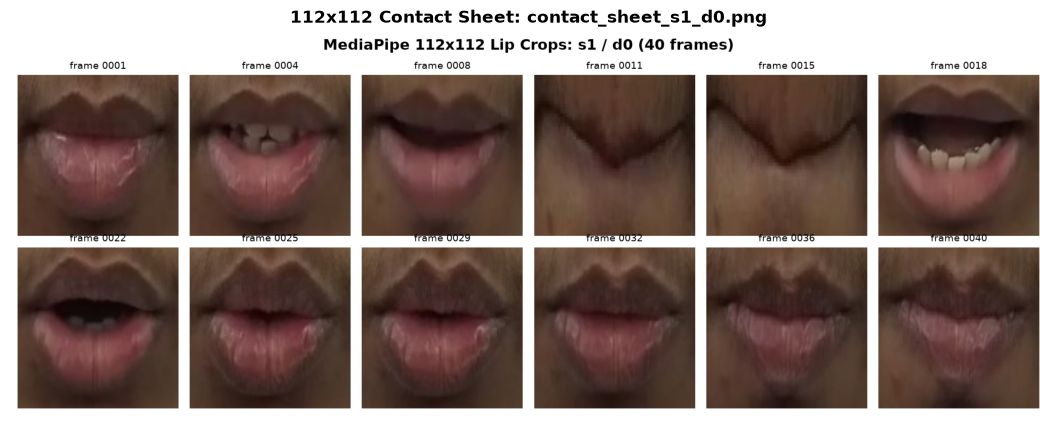

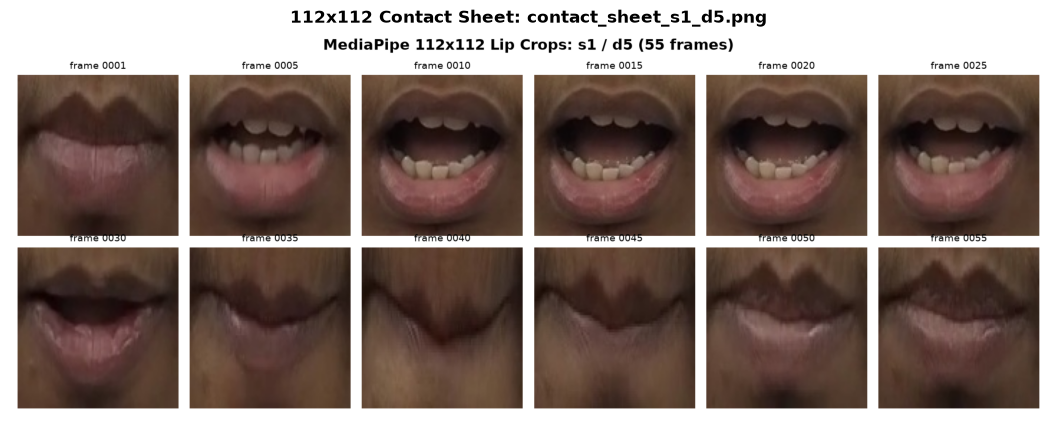

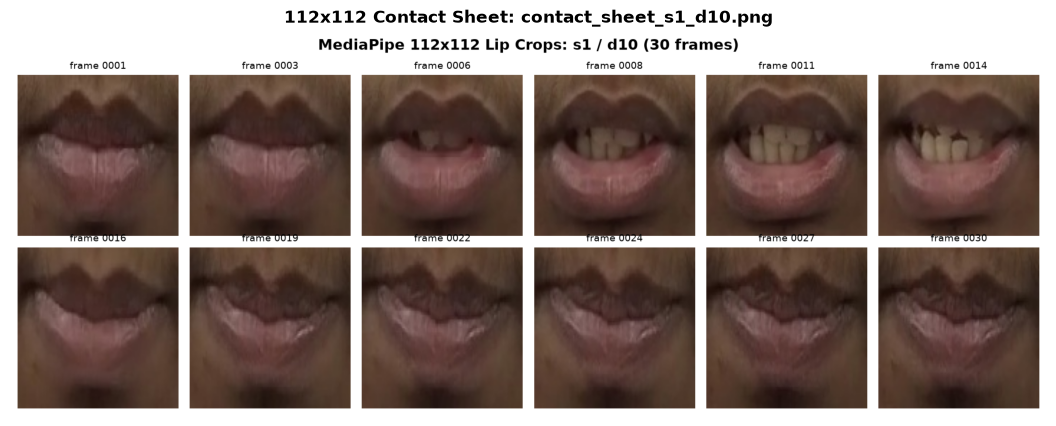

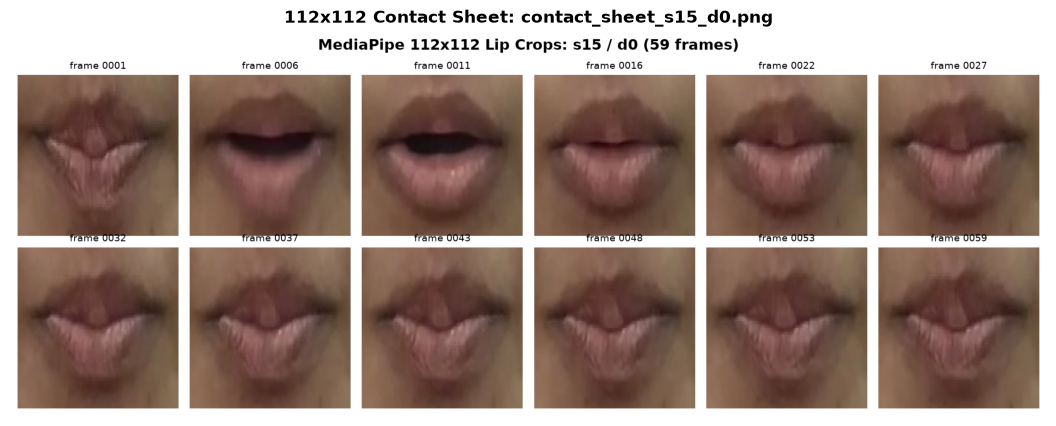

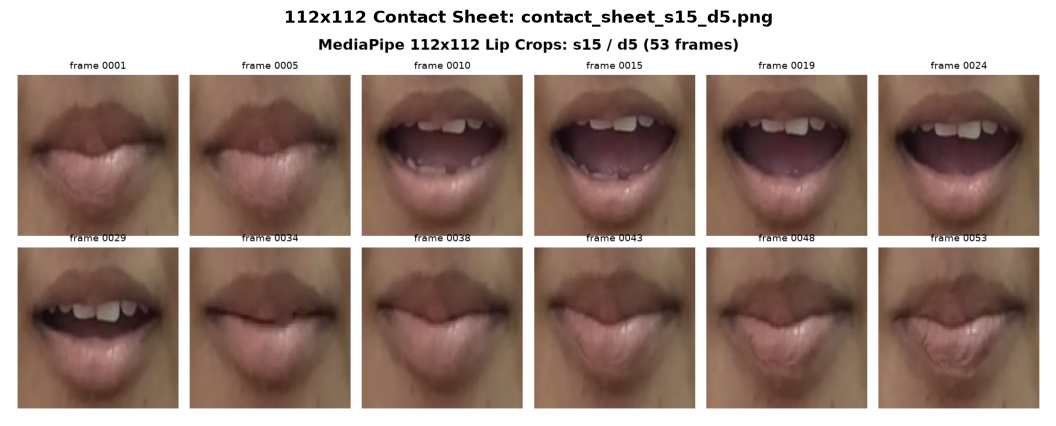

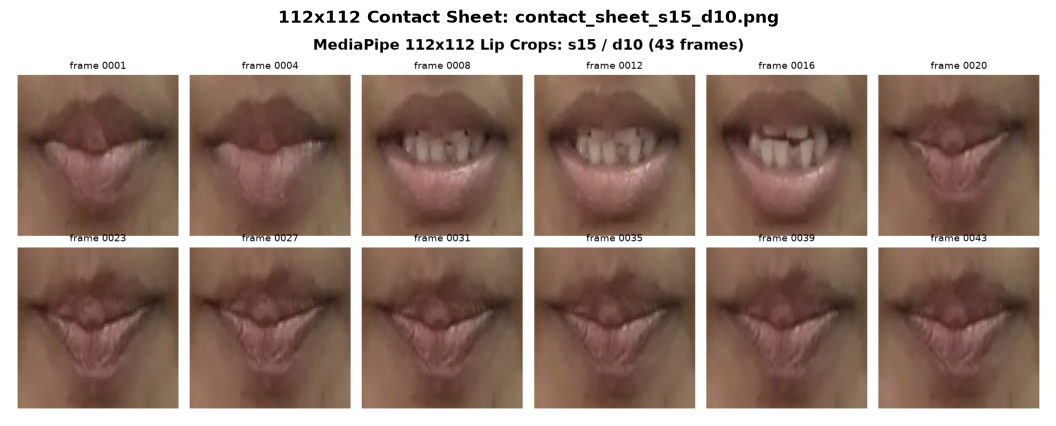

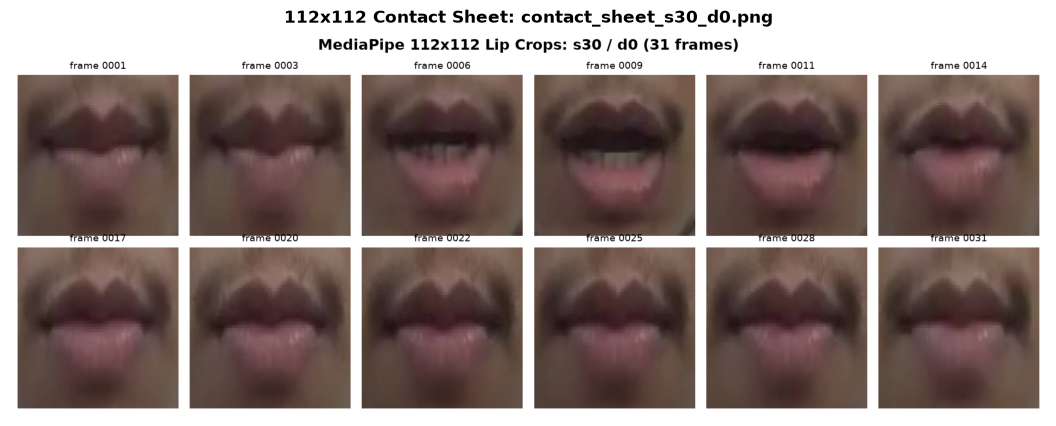

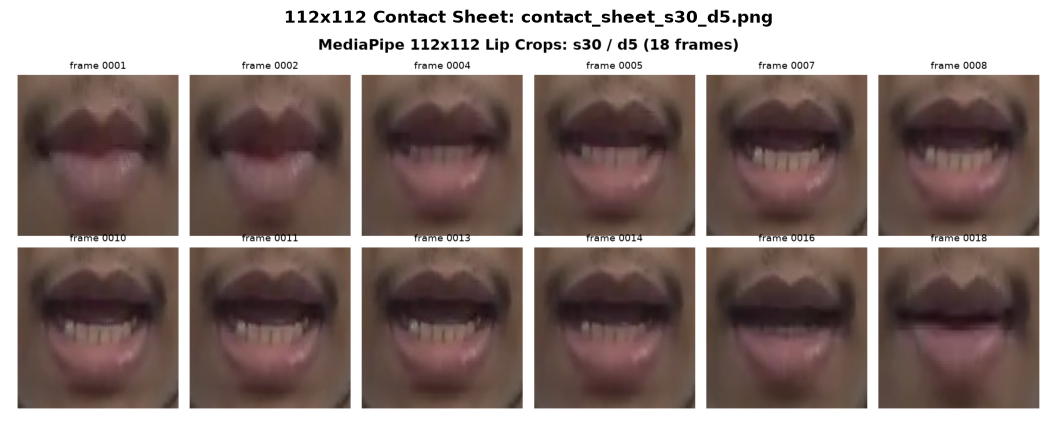

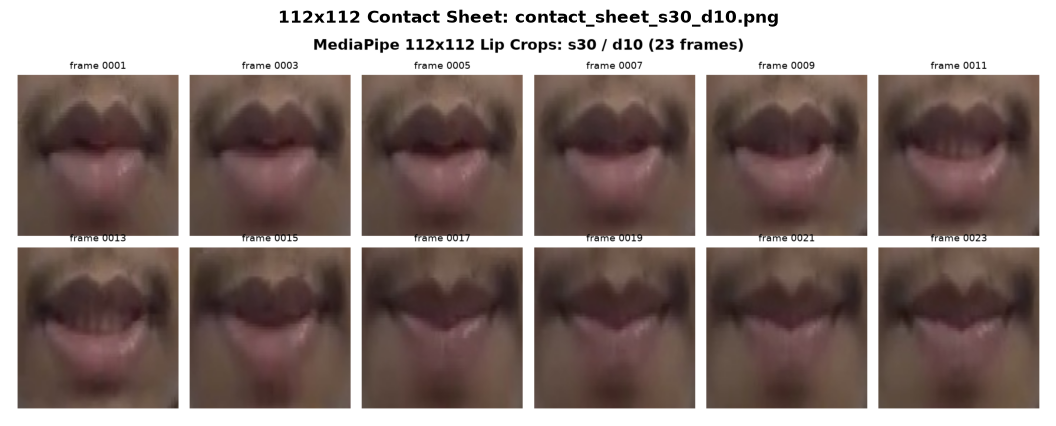

In [6]:
representative_sheets = [
    "contact_sheet_s1_d0.png",
    "contact_sheet_s1_d5.png",
    "contact_sheet_s1_d10.png",
    "contact_sheet_s15_d0.png",
    "contact_sheet_s15_d5.png",
    "contact_sheet_s15_d10.png",
    "contact_sheet_s30_d0.png",
    "contact_sheet_s30_d5.png",
    "contact_sheet_s30_d10.png",
]

for sheet_name in representative_sheets:
    sheet_path = RESULTS_DIR / sheet_name
    if sheet_path.exists():
        img = Image.open(sheet_path)
        plt.figure(figsize=(14, 5))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"112x112 Contact Sheet: {sheet_name}", fontsize=12, fontweight="bold")
        plt.show()
    else:
        print(f"Contact sheet not found: {sheet_path}")

## 6. Visual Comparison: 96×96 vs 112×112 MediaPipe Crops

Direct side-by-side comparison evaluating:
- **Original Source Face ROI**
- **Existing 96×96 MediaPipe Mouth Crop**
- **New 112×112 MediaPipe Mouth Crop**

Found 7 resolution comparison figures in /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/mediapipe_preview_112x112


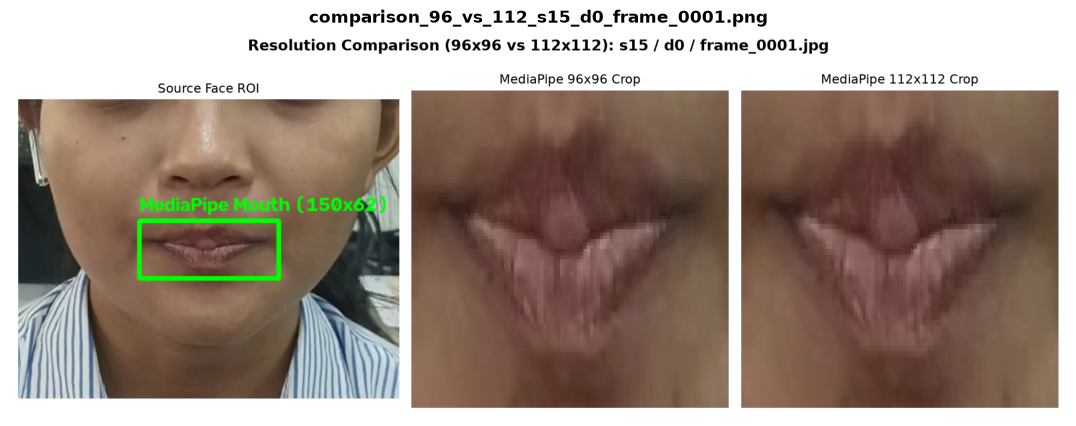

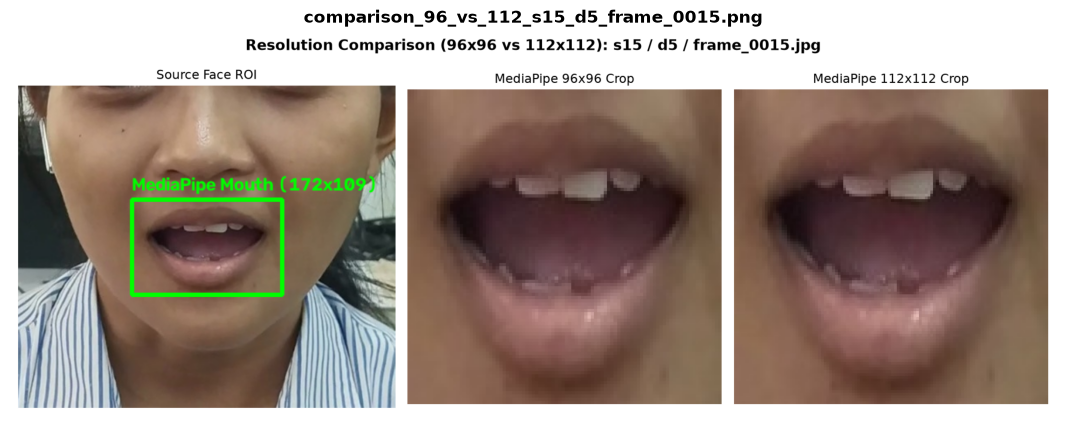

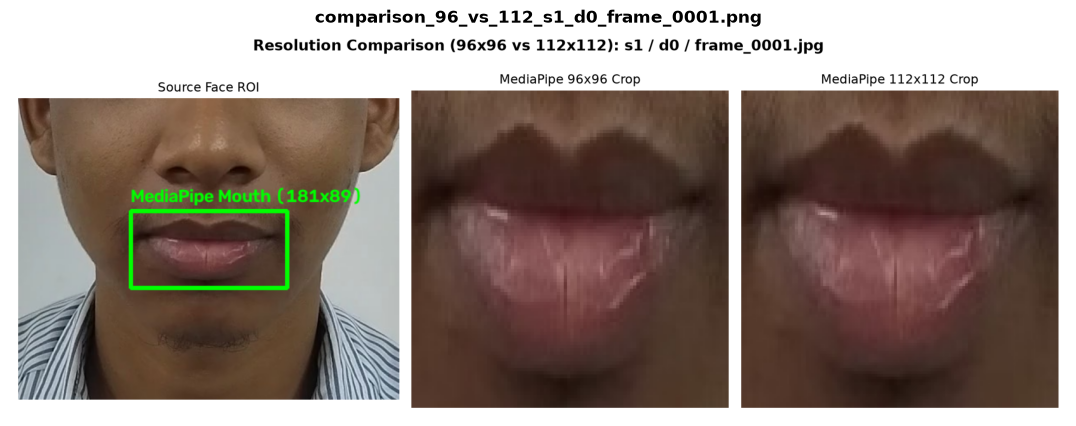

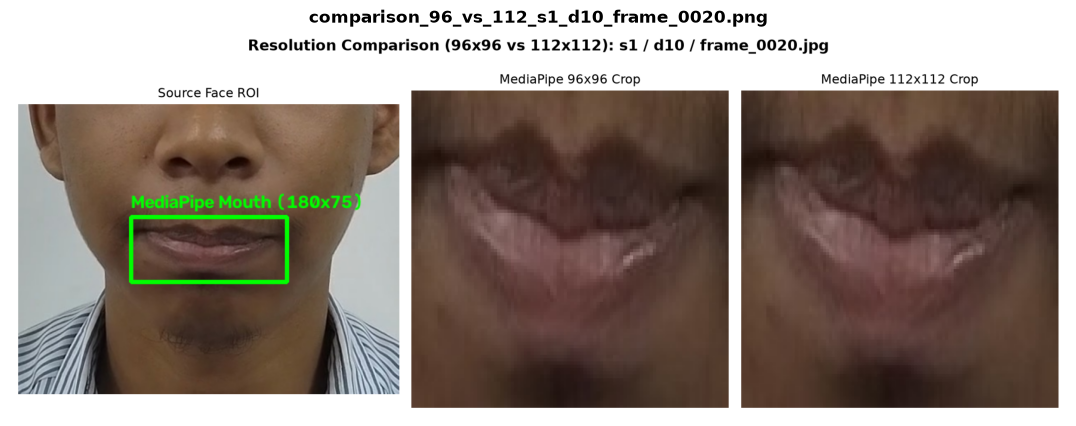

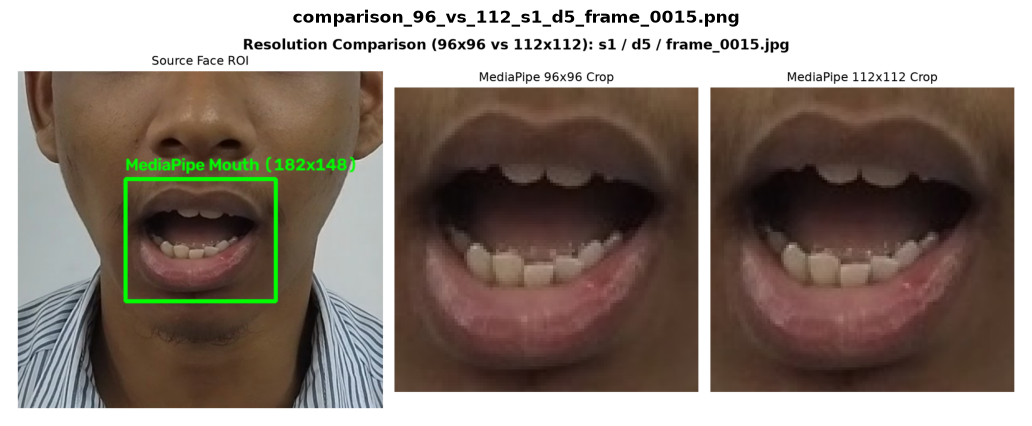

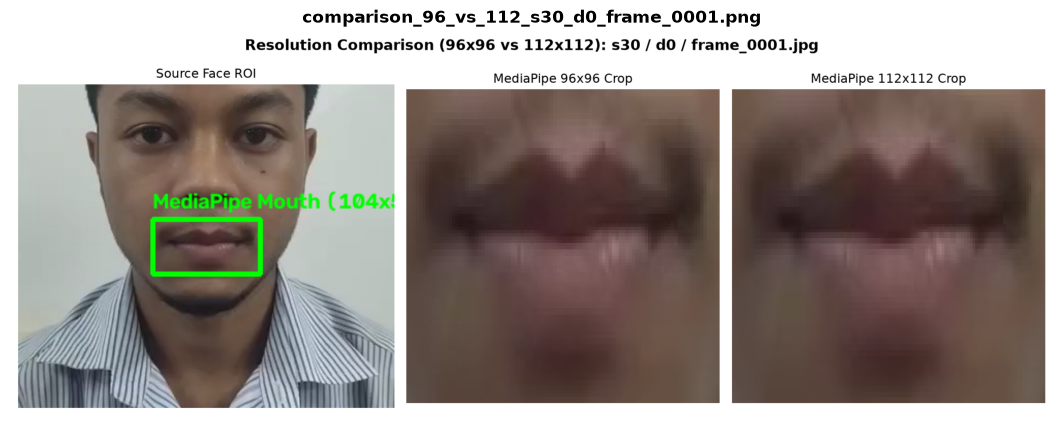

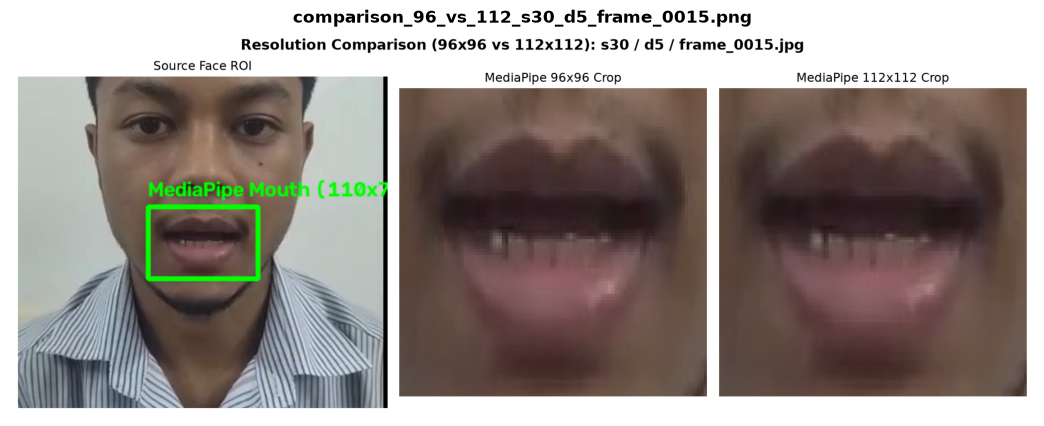

In [7]:
comparison_96_vs_112_images = sorted(list(RESULTS_DIR.glob("comparison_96_vs_112_*.png")))
print(f"Found {len(comparison_96_vs_112_images)} resolution comparison figures in {RESULTS_DIR}")

for comp_path in comparison_96_vs_112_images:
    img = Image.open(comp_path)
    plt.figure(figsize=(14, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(comp_path.name, fontsize=12, fontweight="bold")
    plt.show()

## 7. Resolution & Modeling Analysis: 96×96 vs 112×112

### Key Findings:
1. **Pixel Density Gain**: $112\times 112 = 12,544\text{ pixels/frame}$ vs $96\times 96 = 9,216\text{ pixels/frame}$ ($+36.1\%$ higher resolution).
2. **Lip Boundary Clarity**: Sub-pixel features such as teeth exposure, tongue placement behind incisors, and vermilion border curves are substantially sharper in 112×112.
3. **Neural Backbone Compatibility**: Standard CNN backbones (MobileNetV2, EfficientNet-B0, ResNet-18) natively support spatial downsampling factors of $32\times$ ($112 \to 56 \to 28 \to 14 \to 7$), yielding well-conditioned spatial feature maps ($7\times 7$) ideal for temporal pooling/flattening.

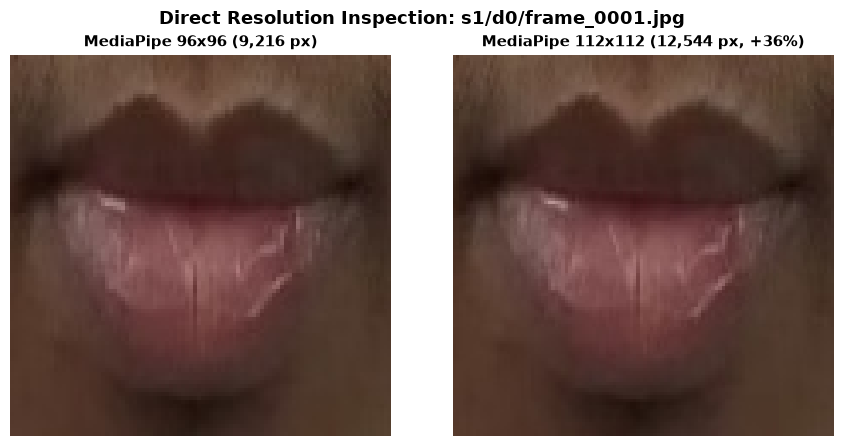

In [8]:
# Direct zoomed comparison between 96x96 and 112x112 for fine inspection
p96 = DATASET_96_DIR / "s1" / "d0" / "frame_0001.jpg"
p112 = OUTPUT_DATASET_DIR / "s1" / "d0" / "frame_0001.jpg"

if p96.exists() and p112.exists():
    im96 = cv2.cvtColor(cv2.imread(str(p96)), cv2.COLOR_BGR2RGB)
    im112 = cv2.cvtColor(cv2.imread(str(p112)), cv2.COLOR_BGR2RGB)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4.5))
    ax1.imshow(im96)
    ax1.set_title(f"MediaPipe 96x96 (9,216 px)", fontsize=11, fontweight="bold")
    ax1.axis("off")
    
    ax2.imshow(im112)
    ax2.set_title(f"MediaPipe 112x112 (12,544 px, +36%)", fontsize=11, fontweight="bold")
    ax2.axis("off")
    plt.suptitle("Direct Resolution Inspection: s1/d0/frame_0001.jpg", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("Frames not found for comparison.")